<a href="https://colab.research.google.com/github/positivefunctionIN/Plant_Leaf_Disease_Prediction_2.0/blob/main/Plant_Leaf_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import numpy as np

print(tf.__version__)

2.20.0


In [ ]:
!pip install -q kaggle

In [ ]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_f8f365ac5c0ba445883f261d2f0f533d"

In [ ]:
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:04<00:00, 162MB/s]



In [ ]:
!unzip plantdisease.zip -d /content/plant_data

Streaming output truncated to the last 5000 lines.
  inflating: /content/plant_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: /content/plant_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: /content/plant_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: /content/plant_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: /content/plant_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: /content/plant_data/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV

In [ ]:
import os
print(os.listdir("/content/plant_data"))

['plantvillage', 'PlantVillage']


In [ ]:
import os

print("plantvillage:", os.listdir("/content/plant_data/plantvillage")[:5])
print("PlantVillage:", os.listdir("/content/plant_data/PlantVillage")[:5])

plantvillage: ['PlantVillage']
PlantVillage: ['Tomato_healthy', 'Tomato_Early_blight', 'Potato___Early_blight', 'Tomato__Tomato_mosaic_virus', 'Potato___healthy']


In [ ]:
dataset_path = "/content/plant_data/PlantVillage"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,519,887 (24.87 MB)

 Trainable params: 6,519,887 (24.87 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_generator,
    validation_data = validation_generator,
    epochs = 10
)

Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 35s 55ms/step - accuracy: 0.5243 - loss: 1.4742 - val_accuracy: 0.7868 - val_loss: 0.6566
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - accuracy: 0.7608 - loss: 0.7189 - val_accuracy: 0.8421 - val_loss: 0.4728
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - accuracy: 0.8257 - loss: 0.5165 - val_accuracy: 0.8549 - val_loss: 0.4277
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.8618 - loss: 0.4114 - val_accuracy: 0.9008 - val_loss: 0.2942
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.8886 - loss: 0.3345 - val_accuracy: 0.8680 - val_loss: 0.3808
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.9101 - loss: 0.2622 - val_accuracy: 0.9199 - val_loss: 0.2338
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.9300 - loss: 0.2121 - val_accuracy: 0.9212 - val_loss: 0.2315
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.9390 - loss: 0.1776 - 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

class_names = list(train_generator.class_indices.keys())
print(f"Class names: {class_names}")

def preprocess_image(image_path):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(128, 128))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array,axis = 0)
    img_array /= 255.0
    return img_array

def predict_image(image_path, model, class_name):
    processed_img = preprocess_image(image_path)
    predictions = model.predict(processed_img, verbose = 0)
    predicted_class_idx = np.argmax(predictions[0])
    predicted_class = class_names[predicted_class_idx]
    confidence = predictions[0][predicted_class_idx] * 100

    top_idx = np.argsort(predictions[0])[-3:][::-1]
    top3 = [(class_names[i], predictions[0][i] * 100) for i in top3_idx]


    return {
        "predicted_class": predicted_class,
        "confidence": confidence,
        "top3": top3,
        "all_probabilities": predictions[0]
    }

    def display_prediction(image_path, result):
        img = tf.keras.utils.load_img(image_path)

        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title(f"Predicted: {result['predicted_class']}\nConfidence: {result['confidence']:.2f}%")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        classes = [r[0] for r in result['top3']]
        confidences = [r[1] for r in result['top3']]
        short_classes = [c.split('___')[-1][:25] for c in classes]

        bars = plt.barh(short_classes, confidences, color='skyblue')
        bars[0].set_color('green')
        plt.xlabel('Confidence (%)')
        plt.title('Top 3 Predictions')

        plt.tight_layout()
        plt.show()

Class names: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


🌿 PLANT DISEASE PREDICTOR

📤 Step 1: Upload a plant leaf image


Saving fdb7d904-91df-4f00-85bd-0fb038723329___RS_LB 2628.JPG to fdb7d904-91df-4f00-85bd-0fb038723329___RS_LB 2628.JPG

🔍 Processing: fdb7d904-91df-4f00-85bd-0fb038723329___RS_LB 2628.JPG


/tmp/ipykernel_4138/672682038.py:55: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4138/672682038.py:55: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4138/672682038.py:55: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_4138/672682038.py:55: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_4138/672682038.py:55: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()


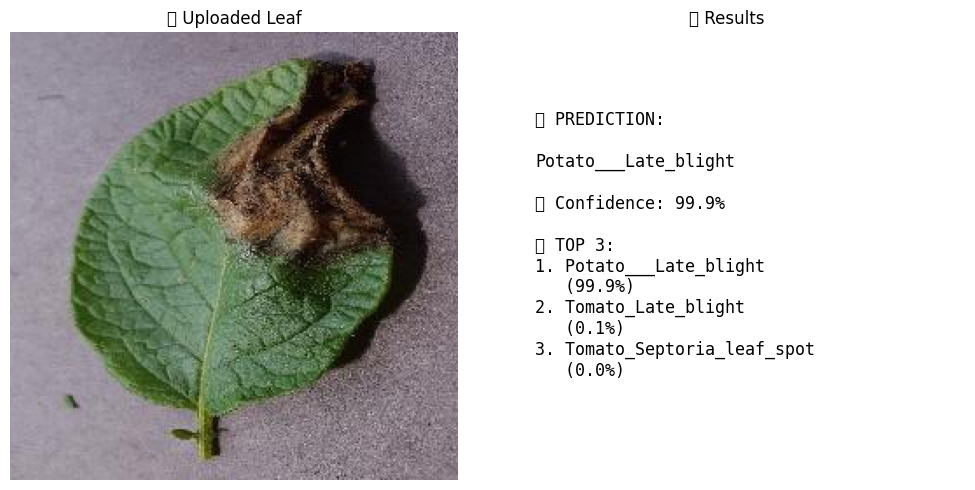


📊 RESULTS:
   ✅ Predicted: Potato___Late_blight
   📈 Confidence: 99.92%

   🏆 Top 3 predictions:
      1. Potato___Late_blight: 99.92%
      2. Tomato_Late_blight: 0.07%
      3. Tomato_Septoria_leaf_spot: 0.00%


In [ ]:
from google.colab import files
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("="*50)
print("🌿 PLANT DISEASE PREDICTOR")
print("="*50)

# Upload image
print("\n📤 Step 1: Upload a plant leaf image")
uploaded = files.upload()

# Class names (from your training)
class_names = list(train_generator.class_indices.keys())

# Process each uploaded image
for filename in uploaded.keys():
    print(f"\n🔍 Processing: {filename}")

    # Step 2: Load and preprocess image
    img = tf.keras.utils.load_img(filename, target_size=(128, 128))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0  # Normalize

    # Step 3: Make prediction
    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx] * 100

    # Get top 3 predictions
    top3_idx = np.argsort(predictions[0])[-3:][::-1]

    # Step 4: Display result
    plt.figure(figsize=(10, 5))

    # Show image
    plt.subplot(1, 2, 1)
    plt.imshow(tf.keras.utils.load_img(filename))
    plt.title(f"🌱 Uploaded Leaf", fontsize=12)
    plt.axis('off')

    # Show prediction text
    plt.subplot(1, 2, 2)
    plt.axis('off')
    result_text = f"✅ PREDICTION:\n\n{class_names[predicted_class_idx]}\n\n📊 Confidence: {confidence:.1f}%\n\n"
    result_text += f"🏆 TOP 3:\n"
    for i, idx in enumerate(top3_idx):
        result_text += f"{i+1}. {class_names[idx]}\n   ({predictions[0][idx]*100:.1f}%)\n"

    plt.text(0.1, 0.5, result_text, fontsize=12, verticalalignment='center', fontfamily='monospace')
    plt.title("📋 Results", fontsize=12)

    plt.tight_layout()
    plt.show()

    # Print to console
    print(f"\n📊 RESULTS:")
    print(f"   ✅ Predicted: {class_names[predicted_class_idx]}")
    print(f"   📈 Confidence: {confidence:.2f}%")
    print(f"\n   🏆 Top 3 predictions:")
    for i, idx in enumerate(top3_idx):
        print(f"      {i+1}. {class_names[idx]}: {predictions[0][idx]*100:.2f}%")

In [1]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

In [4]:
def make_gradcam_heatmap(image_batch, model, last_conv_layer_name, pred_index=None):
    """
    Generates a Grad-CAM heatmap for a single image.

    PARAMETERS:
    -----------
    image_batch : numpy array
        Preprocessed image with shape (1, height, width, channels)
        Example: shape (1, 128, 128, 3)

    model : tf.keras.Model
        Your trained Keras model

    last_conv_layer_name : str
        Name of the last convolutional layer in your model.
        For your model, this is "conv2d_2"

    pred_index : int or None
        If None: uses the model's predicted class
        If int: uses that specific class index

    RETURNS:
    --------
    heatmap : numpy array
        2D array of shape (height, width) with values between 0 and 1
        Higher values = more important for the prediction
    """

    # Step 1: Create a new model that outputs TWO things:
    #   - The last convolutional layer's output (for spatial info)
    #   - The final predictions (for class scores)
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,  # conv features
            model.output                                   # predictions
        ]
    )

    # Step 2: Use GradientTape to record operations for automatic differentiation
    with tf.GradientTape() as tape:
        # Forward pass: get conv features AND predictions
        conv_output, predictions = grad_model(image_batch)

        # Determine which class we care about
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])  # predicted class

        # Get the score for that specific class
        loss = predictions[:, pred_index]

    # Step 3: Calculate gradients of the loss w.r.t. the conv output
    # This tells us: "How much does each neuron's output affect the final score?"
    grads = tape.gradient(loss, conv_output)

    # Step 4: Global Average Pooling of gradients
    # For each feature map (channel), we average the gradients across space
    # This gives us ONE weight per feature map
    # Shape: (batch_size, num_filters) -> we take first batch
    weights = tf.reduce_mean(grads, axis=(1, 2))  # shape: (1, num_filters)

    # Step 5: Weighted sum of feature maps
    # Each feature map is multiplied by its importance weight
    # Shape: (1, height, width, num_filters) -> sum over last axis -> (1, height, width)
    heatmap = tf.reduce_sum(tf.multiply(weights, conv_output), axis=-1)

    # Step 6: Apply ReLU (remove negative influences)
    # Negative values would indicate features that HURT the class score
    heatmap = tf.maximum(heatmap, 0)

    # Step 7: Normalize to range [0, 1]
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-10)

    # Return as numpy array (remove batch dimension)
    return heatmap.numpy()[0]